In [3]:
%load_ext autoreload
%autoreload 2

from pool_genes import *
from gradientVersion import *
from brainspan import *
from processing import *

/home/gchan/kg98_scratch/gchan/SIR_SCZ/SIR_utils/.venv/lib/python3.14/site-packages/neuromaps/datasets/utils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


In [27]:
gene_expr = get_abagen_by_roi(
    fetch_hcp(),
    donors_threshold=3,
    gene_stability_threshold=0.5,
    save_name='hcp_3d_ds5'
    )

INFO: Donor-specific atlases provided; using native coords for tissue samples
/home/gchan/kg98_scratch/gchan/SIR_SCZ/SIR_utils/.venv/lib/python3.14/site-packages/abagen/mouse/io.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename
/home/gchan/kg98_scratch/gchan/SIR_SCZ/SIR_utils/.venv/lib/python3.14/site-packages/abagen/mouse/io.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename
/home/gchan/kg98_scratch/gchan/SIR_SCZ/SIR_utils/.venv/lib/python3.14/site-packages/abagen/mouse/io.py:7: UserWarning: pkg_resources i

154 / 196 regions remain after filtering for regions with samples from >= 3 donors
7819 / 15637 genes remain after filtering for top 0.5 stability
Expression matrix saved to ../data/abagen-data/expression/hcp_3d_ds5.csv


In [4]:
# gene_expr = pd.read_csv('../../abagen_get/results/gene_expr_s132_indiv.csv', index_col=0)
gene_expr = pd.read_csv('../data/abagen-data/expression/s100ts2_0d_ds5.csv', index_col=0)

gene_df = pd.read_csv('../data/260303_gene_pair_pvalues.csv')
gene_df["pass_all"] = (
    (gene_df["p_spatial_fdr"] < 0.05)
    & (gene_df["p_rewired_fdr"] < 0.05)
    & (gene_df["p_gene_fdr"] < 0.05)
).astype(int)

risk_df_full = pool_genes(gene_df, "risk gene")
risk_df = risk_df_full[risk_df_full["pass_all"] == True]

symbols = [g for g in risk_df["abagen symbol"] if g in gene_expr.columns]
risk_expr = gene_expr.loc[:, symbols]

print(f'gene_expr shape (filtered rows kept): {gene_expr.shape}')
print(f'all-NaN regions before DME: {risk_expr.isna().all(axis=1).sum()}')

gene_expr shape (filtered rows kept): (66, 7819)
all-NaN regions before DME: 0


In [5]:
dme_results = gradientVersion(approach='dm', kernel='normalized_angle', alpha=1, n_components=5).fit(risk_expr)

Aligning gradient 1 to marker gene PKDCC...
Aligning gradient 2 to marker gene IFT22...
Aligning gradient 3 to marker gene SIPA1L1...
New gradients version: method=dm, kernel=normalized_angle, sparsity=0, data=(data given)


In [4]:
import pandas as pd
import numpy as np
import yabplot as yab
from pyvista import Plotter

import pyvista as pv
pv.global_theme.transparent_background = True

def label_for_yab(data, atlas: str = "Schaefer") -> dict:
    if atlas == "Schaefer":
        labels = np.genfromtxt(
            '/fs03/kg98/gchan/Atlases/Tian/tian_atlas/yab_labels.csv',
            dtype=str,
        )
        n_regions = 66
    elif atlas == "Glasser":
        glasser_lut = pd.read_csv(
            '/fs03/kg98/gchan/Atlases/Glasser/fsLR_32k_Glasser360+TianS2.txt',
            header=None,
            sep=r'\s+',
        )
        labels = glasser_lut.iloc[:196, 0].to_numpy()
        n_regions = 196

    if isinstance(data, pd.Series):
        values = data.reindex(np.arange(n_regions)+1)
    else:
        arr = np.asarray(data).ravel()
        values = pd.Series(arr, index=np.arange(n_regions)).reindex(np.arange(n_regions)+1)

    return dict(zip(labels, values.to_numpy()))

def set_yab_scalebar(
        pl: Plotter, font_size: int = 10, label_format: str = None, hide_sb: bool = False,
        show: bool = True, export_path: str = None) -> None:
    sbar = next(iter(pl.scalar_bars.values()))          # get colorbar object
    if hide_sb:
        sbar.SetVisibility(False)                      # hide colorbar if specified
    else:
        sbar.GetLabelTextProperty().SetFontSize(font_size)  # set colorbar label font size
        if label_format is not None:
            sbar.SetLabelFormat(label_format)               # control numeric label formatting
    if export_path:
        pl.screenshot(export_path, transparent_background=True)
        show = False
    if show:
        pl.show(jupyter_backend='static')
    pl.close()

tian_dir = "/fs03/kg98/gchan/Atlases/Tian/tian_atlas/surfaces"

Plotting 1...


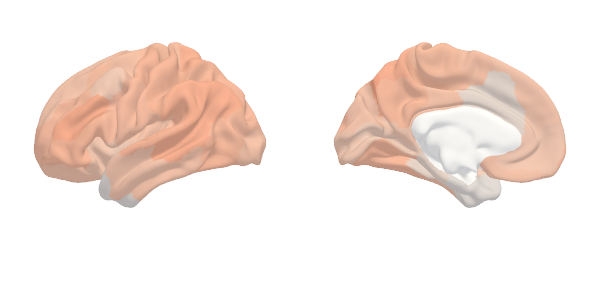

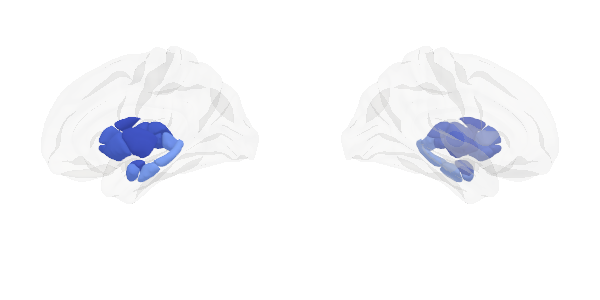

Plotting 2...


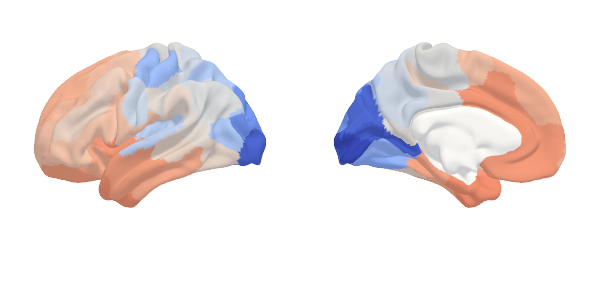

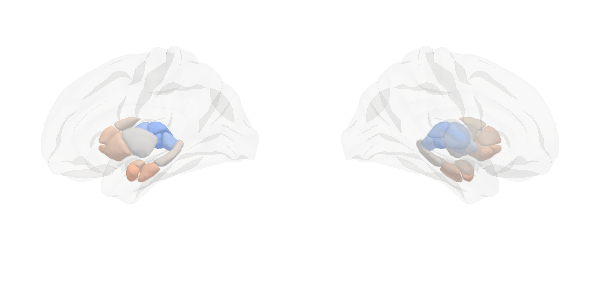

Plotting 3...


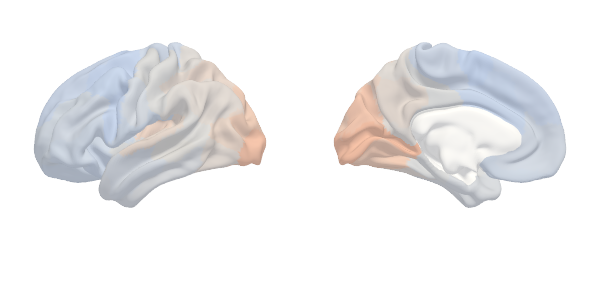

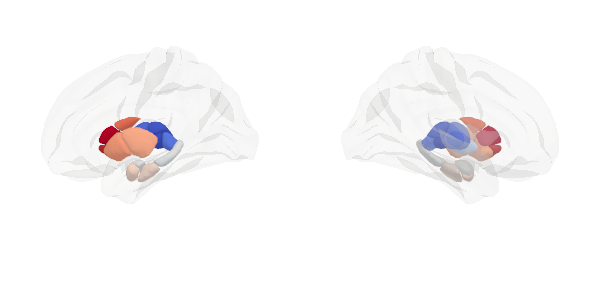

Plotting 4...


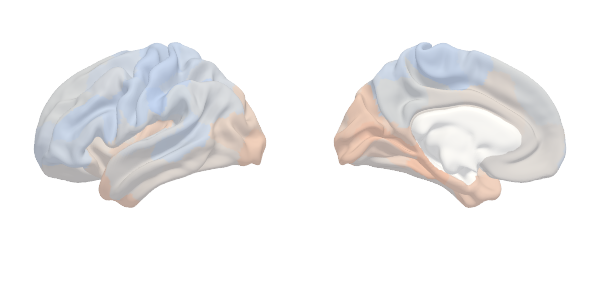

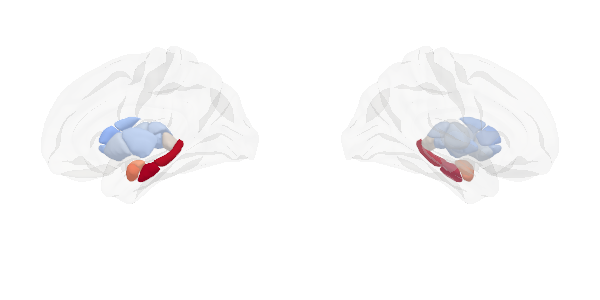

In [111]:
glasser_dir = "/fs03/kg98/gchan/Atlases/Glasser"
tian_dir = "/fs03/kg98/gchan/Atlases/Tian/tian_atlas/surfaces"

for component in dme_results.scores.columns[:4]:
    print(f"Plotting {component + 1}...")
    data = dme_results.scores[component]
    data_dict = label_for_yab(data, atlas="Schaefer")
    lim = np.nanmax(np.abs(data))
    pl = yab.plot_cortical(
        data=data_dict, atlas="schaefer_100", display_type="object",
        views=['left_lateral', 'left_medial'], figsize=(600, 300), cmap='coolwarm',
        vminmax=(-lim, lim)
    )
    set_yab_scalebar(pl, hide_sb=True)
    pl = yab.plot_subcortical(
        data=data_dict, custom_atlas_path=tian_dir, display_type='object', bmesh_alpha=0.2,
        figsize=(600, 300), cmap='coolwarm', views=['left_lateral', 'left_medial'],
        vminmax=(-lim, lim)
    )
    set_yab_scalebar(pl, hide_sb=True)

In [6]:
hcp_bs_mapping = get_hcp_bs_mapping_v2()

In [7]:
bs_exp, bs_col, bs_row = get_brainspan()
bs_clean = clean_brainspan(bs_exp, bs_col, bs_row, hcp_bs_mapping)
bs_agg = aggregate_brainspan_by_age(bs_clean)

/fs04/scratch2/kg98/oldscratch/gchan/SIR_SCZ/SIR_utils/enrichment/scripts/brainspan.py:410: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bs_clean = bs_clean.groupby(["donor_id", "age"]).apply(
/home/gchan/kg98_scratch/gchan/SIR_SCZ/SIR_utils/.venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:4062: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


In [8]:
hcp_mapped_scores = get_mapped_scores(dme_results, hcp_bs_mapping)
bs_scores = compute_brainspan_scores(bs_agg, dme_results, n_components=4)

<class 'NoneType'> None
<class 'pandas.core.frame.DataFrame'> (66, 5)


/fs04/scratch2/kg98/oldscratch/gchan/SIR_SCZ/SIR_utils/enrichment/scripts/brainspan.py:436: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bs_scores = bs_scores.groupby("age").apply(
/fs04/scratch2/kg98/oldscratch/gchan/SIR_SCZ/SIR_utils/enrichment/scripts/brainspan.py:442: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bs_scores = bs_scores.groupby("age").apply(
/home/gchan/kg98_scratch/gchan/SIR_SCZ/SIR_utils/.venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:4062: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and retu

In [9]:
age_groups = get_age_groups()
bs_scores_corr = correlate_brainspan_scores(bs_scores, hcp_mapped_scores, age_groups=age_groups)
bs_scores_corr.sort_values('age')

,age,C,corr,sem
0,18-40 yrs,C1,0.981944,0.035786
1,18-40 yrs,C2,0.168591,0.971577
2,18-40 yrs,C3,0.783961,0.385404
3,18-40 yrs,C4,0.401526,0.838777
4,Birth-13 yrs,C1,0.830697,0.309943
5,Birth-13 yrs,C2,0.875736,0.233087
6,Birth-13 yrs,C3,0.599608,0.640470
7,Birth-13 yrs,C4,0.337000,0.886431
8,Pre-Birth,C1,0.187232,0.964944
9,Pre-Birth,C2,0.853273,0.271926


In [10]:
bs_donor_ages = (bs_clean
 .index.to_frame(index=False)
 .loc[:, ['age', 'donor_id']]
 .assign(age_log10 = lambda x: age_to_continuous(x['age']).pipe(np.log10))
 .groupby('donor_id').max()
 .sort_values('age')
 .assign(age_n = lambda x: x.groupby('age').cumcount())
)

/tmp/ipykernel_3245239/893738719.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .assign(age_n = lambda x: x.groupby('age').cumcount())


In [10]:
weights = dme_results.weights.iloc[:, :4].copy()

curves = get_brainspan_curves_by_gene(genes=list(weights.index))
quantile_curves = get_quantile_curves(weights, curves, q=10)

/fs04/scratch2/kg98/oldscratch/gchan/SIR_SCZ/SIR_utils/enrichment/scripts/brainspan.py:271: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda y: y["pred"] / np.quantile(y["pred"], 0.75))


BrainSpan curves saved to ../results/brainspan_curves.csv


/fs04/scratch2/kg98/oldscratch/gchan/SIR_SCZ/SIR_utils/enrichment/scripts/brainspan.py:97: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["C", "C_quantile", "age_log10"])


In [12]:
weights = dme_results.weights.iloc[:, :4].copy()

bs_c_map = pd.read_csv('../data/bs_component_mapping.csv')
direction = -1
c1rois = bs_c_map[bs_c_map["C1"]==direction]["structure_acronym"].tolist()
c2rois = bs_c_map[bs_c_map["C2"]==direction]["structure_acronym"].tolist()
c3rois = bs_c_map[bs_c_map["C3"]==direction]["structure_acronym"].tolist()
c4rois = bs_c_map[bs_c_map["C4"]==direction]["structure_acronym"].tolist()

c1curves = get_brainspan_curves_by_gene(genes=list(weights.index[:]), regions=c1rois)
c2curves = get_brainspan_curves_by_gene(genes=list(weights.index[:]), regions=c2rois)
c3curves = get_brainspan_curves_by_gene(genes=list(weights.index[:]), regions=c3rois)
c4curves = get_brainspan_curves_by_gene(genes=list(weights.index[:]), regions=c4rois)

c1_quantiles = get_quantile_curves(weights, c1curves, q=10)
c2_quantiles = get_quantile_curves(weights, c2curves, q=10)
c3_quantiles = get_quantile_curves(weights, c3curves, q=10)
c4_quantiles = get_quantile_curves(weights, c4curves, q=10)

/fs04/scratch2/kg98/oldscratch/gchan/SIR_SCZ/SIR_utils/enrichment/scripts/brainspan.py:271: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda y: y["pred"] / np.quantile(y["pred"], 0.75))


BrainSpan curves saved to ../results/brainspan_curves.csv


/fs04/scratch2/kg98/oldscratch/gchan/SIR_SCZ/SIR_utils/enrichment/scripts/brainspan.py:271: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda y: y["pred"] / np.quantile(y["pred"], 0.75))


BrainSpan curves saved to ../results/brainspan_curves.csv


/fs04/scratch2/kg98/oldscratch/gchan/SIR_SCZ/SIR_utils/enrichment/scripts/brainspan.py:271: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda y: y["pred"] / np.quantile(y["pred"], 0.75))


BrainSpan curves saved to ../results/brainspan_curves.csv


/fs04/scratch2/kg98/oldscratch/gchan/SIR_SCZ/SIR_utils/enrichment/scripts/brainspan.py:271: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda y: y["pred"] / np.quantile(y["pred"], 0.75))


BrainSpan curves saved to ../results/brainspan_curves.csv


/fs04/scratch2/kg98/oldscratch/gchan/SIR_SCZ/SIR_utils/enrichment/scripts/brainspan.py:97: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["C", "C_quantile", "age_log10"])
/fs04/scratch2/kg98/oldscratch/gchan/SIR_SCZ/SIR_utils/enrichment/scripts/brainspan.py:97: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["C", "C_quantile", "age_log10"])
/fs04/scratch2/kg98/oldscratch/gchan/SIR_SCZ/SIR_utils/enrichment/scripts/brainspan.py:97: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior 

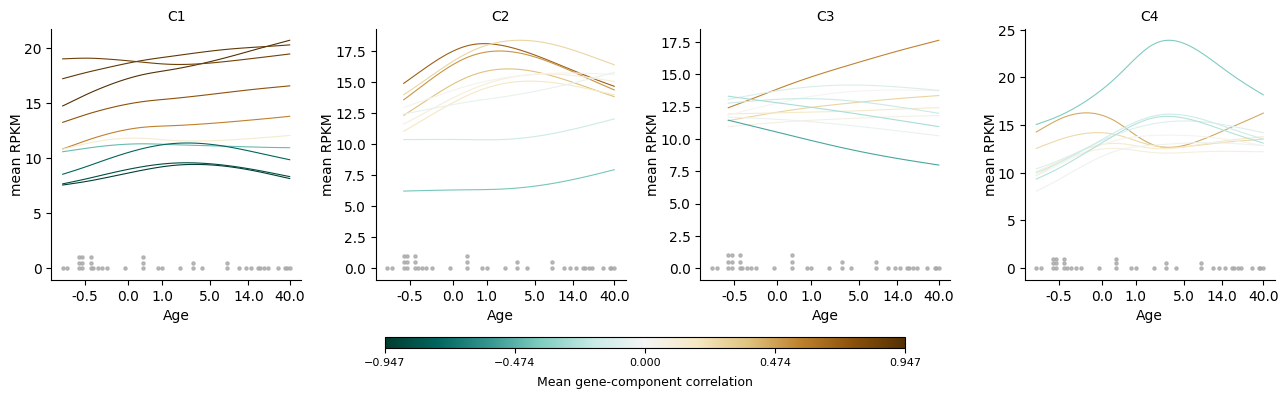

In [13]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

def plot_quantile_curves(
    quantile_curves,
    donor_ages=None,
    facet="C",
    ytitle_rmargin=0,
    ncol=3,
    which="pred",
    weights_df=None,
):
    facet = facet[1:] if facet.startswith("~") else facet

    def _prep_df(df):
        out = df.copy()
        out["curve"] = pd.to_numeric(out[which], errors="coerce")
        out = out.dropna(subset=["age_log10", "C_quantile", "curve"])
        return out

    def _facet_sort_key(x):
        sx = str(x)
        digits = "".join(ch for ch in sx if ch.isdigit())
        return (0, int(digits)) if digits else (1, sx)

    def _score_summary(weights_df, q):
        quantiles = get_weight_quantiles(weights_df, q=q).copy()
        quantiles["C_quantile"] = quantiles["C_quantile"].astype(int)
        return (
            quantiles.groupby(["C", "C_quantile"], as_index=False)
            .agg(mean_score=("C_score", "mean"))
            .sort_values(["C", "C_quantile"])
        )

    # Accept either one shared quantile DataFrame or per-facet DataFrames.
    if isinstance(quantile_curves, pd.DataFrame):
        df_all = _prep_df(quantile_curves)
        if facet not in df_all.columns:
            raise ValueError(f"Expected facet column '{facet}' in quantile_curves")
        facet_vals = sorted(pd.unique(df_all[facet].dropna()), key=_facet_sort_key)
        data_by_facet = {fval: df_all[df_all[facet] == fval] for fval in facet_vals}
    elif isinstance(quantile_curves, dict):
        data_by_facet = {}
        for key, df in quantile_curves.items():
            dfi = _prep_df(df)
            if facet not in dfi.columns:
                dfi[facet] = key
            dfi = dfi[dfi[facet] == key]
            if not dfi.empty:
                data_by_facet[key] = dfi
        if not data_by_facet:
            raise ValueError("No valid quantile curve data found in dict input")
        facet_vals = sorted(data_by_facet.keys(), key=_facet_sort_key)
        df_all = pd.concat(data_by_facet.values(), ignore_index=True)
    elif isinstance(quantile_curves, (list, tuple)):
        data_by_facet = {}
        for i, df in enumerate(quantile_curves, start=1):
            dfi = _prep_df(df)
            if facet in dfi.columns:
                facet_unique = pd.unique(dfi[facet].dropna())
                if len(facet_unique) == 1:
                    fval = facet_unique[0]
                elif len(facet_unique) == 0:
                    fval = f"C{i}"
                    dfi[facet] = fval
                else:
                    for sub_fval in facet_unique:
                        sub = dfi[dfi[facet] == sub_fval]
                        if not sub.empty:
                            data_by_facet[sub_fval] = sub
                    continue
            else:
                fval = f"C{i}"
                dfi[facet] = fval

            dfi = dfi[dfi[facet] == fval]
            if not dfi.empty:
                data_by_facet[fval] = dfi

        if not data_by_facet:
            raise ValueError("No valid quantile curve data found in list/tuple input")
        facet_vals = sorted(data_by_facet.keys(), key=_facet_sort_key)
        df_all = pd.concat(data_by_facet.values(), ignore_index=True)
    else:
        raise TypeError("quantile_curves must be a DataFrame, dict, list, or tuple")

    q_levels = pd.unique(df_all["C_quantile"])[::-1]
    score_summary = None
    if weights_df is not None:
        score_summary = _score_summary(weights_df, q=len(q_levels))

    fig, axes = plt.subplots(
        math.ceil(len(facet_vals) / ncol),
        ncol,
        figsize=(3.25 * ncol, 3.0 * math.ceil(len(facet_vals) / ncol) + 0.8),  # Added height room for horizontal cbar
        squeeze=False,
    )
    axes_flat = axes.ravel()

    if score_summary is not None and not score_summary.empty:
        cmap = plt.get_cmap("BrBG_r")
        # Enforce symmetrical colorbar limits around 0
        max_abs = max(abs(score_summary["mean_score"].min()), abs(score_summary["mean_score"].max()))
        score_min = -max_abs
        score_max = max_abs
        
        if np.isclose(score_min, score_max):
            score_min -= 1e-9
            score_max += 1e-9
        norm = Normalize(vmin=score_min, vmax=score_max)
    else:
        cmap = plt.get_cmap("BrBG_r", max(len(q_levels), 10))
        norm = None

    x_break_vals = np.array([-0.5, 0, 1, 5, 14, 40], dtype=float)
    x_breaks = np.log10(x_break_vals * 365 + 40 * 7)
    x_labels = [str(round((10 ** x - 40 * 7) / 365, 2)) for x in x_breaks]

    for i, fval in enumerate(facet_vals):
        ax = axes_flat[i]
        dfi = data_by_facet[fval].sort_values("C_quantile", ascending=False)
        comp_scores = None
        if score_summary is not None and fval in score_summary["C"].values:
            comp_scores = score_summary[score_summary["C"] == fval].set_index("C_quantile")["mean_score"]

        for q in q_levels:
            dq = dfi[dfi["C_quantile"] == q].sort_values("age_log10")
            if dq.empty:
                continue
            if comp_scores is not None and q in comp_scores.index:
                line_color = cmap(norm(comp_scores.loc[q]))
            else:
                line_color = cmap(q)
            ax.plot(dq["age_log10"], 10 ** dq["curve"], color=line_color, lw=0.8)
        if donor_ages is not None and {"age_log10", "age_n"}.issubset(donor_ages.columns):
            ax.scatter(donor_ages["age_log10"], donor_ages["age_n"] / 2.0, s=5, color="darkgrey", alpha=0.8)
        ax.set_title(str(fval), fontsize=10)
        ax.set_xticks(x_breaks)
        ax.set_xticklabels(x_labels)
        ax.set_xlabel("Age")
        ax.set_ylabel("mean RPKM", labelpad=ytitle_rmargin)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    for j in range(len(facet_vals), len(axes_flat)):
        axes_flat[j].axis("off")

    fig.tight_layout()

    if score_summary is not None and not score_summary.empty:
        fig.subplots_adjust(bottom=0.25)
        # Format: [left, bottom, width, height] relative to the whole figure (0 to 1)
        cbar_ax = fig.add_axes([0.3, 0.07, 0.4, 0.03]) 
        
        sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])
        
        cbar = fig.colorbar(
            sm,
            cax=cbar_ax,       # Use our dedicated independent axis
            orientation="horizontal"
        )
        cbar.set_label("Mean gene-component correlation", fontsize=9, labelpad=6)
        cbar.set_ticks(np.linspace(score_min, score_max, 5))
        cbar.ax.tick_params(labelsize=8)
    else:
        handles = [
            plt.Line2D([0], [0], color=cmap(q), lw=2, label=str(k))
            for k, q in enumerate(q_levels, start=1)
        ]
        fig.legend(handles=handles, title="Decile", loc="upper right", frameon=False)

    return fig, axes

quantile_input = {
    "C1": c1_quantiles,
    "C2": c2_quantiles,
    "C3": c3_quantiles,
    "C4": c4_quantiles,
}

# quantile_input = quantile_curves

fig, axes = plot_quantile_curves(
    quantile_curves=quantile_input,
    donor_ages=bs_donor_ages,
    facet="C",
    ncol=4,
    which="pred",
    weights_df=weights,
)
# plt.show()
plt.savefig('../results/brainspan_quantile_curves_neg.svg', bbox_inches='tight')

In [14]:
import numpy as np
import pandas as pd

weights_long = weights.rename_axis("gene").reset_index().melt(id_vars="gene", var_name="C", value_name="loading")
curves_with_weights = curves.merge(weights_long, on="gene", how="inner")

def compute_weighted_curve(df):
    tmp = df.assign(y=10 ** df["pred"], wy=lambda x: x["loading"] * x["y"])
    out = tmp.groupby("age_log10", as_index=False).agg(wy=("wy", "sum"), w=("loading", "sum"))
    out["pred"] = np.log10(np.maximum(out["wy"] / out["w"], 1e-10))
    return out[["age_log10", "pred"]]

rows = []
for comp in weights.columns:
    comp_df = curves_with_weights[curves_with_weights["C"] == comp]
    for group, group_df in {"all": comp_df, "positive": comp_df[comp_df["loading"] > 0], "negative": comp_df[comp_df["loading"] < 0]}.items():
        if group_df.empty:
            continue
        curve = compute_weighted_curve(group_df)
        curve["C"] = comp
        curve["group"] = group
        rows.append(curve)

weighted_curves_df = pd.concat(rows, ignore_index=True)

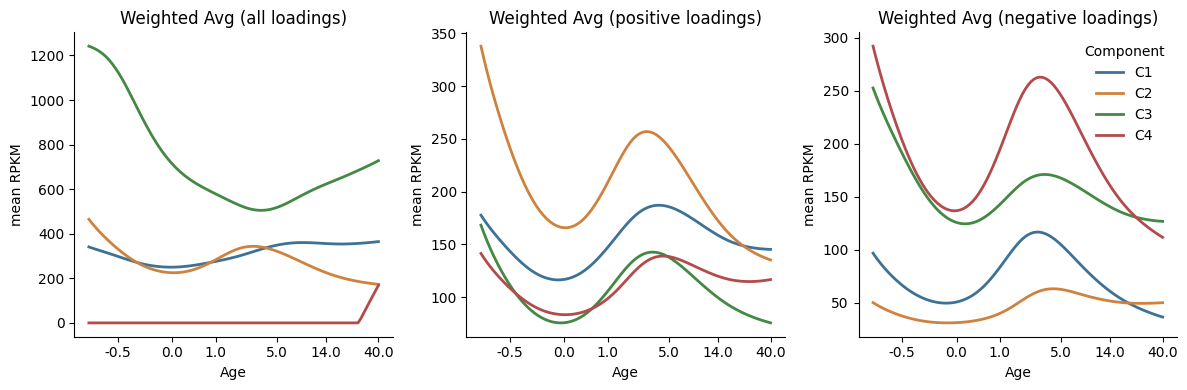

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

x_break_vals = np.array([-0.5, 0, 1, 5, 14, 40], dtype=float)
x_breaks = np.log10(x_break_vals * 365 + 40 * 7)
x_labels = [str(round((10 ** x - 40 * 7) / 365, 2)) for x in x_breaks]
comp_order = sorted(weights.columns, key=lambda x: int(str(x).lstrip('C'))) 
colors = [sns.desaturate(c, 0.6) for c in sns.color_palette("tab10", len(comp_order))]
groups = ['all', 'positive', 'negative']
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True)

for ax, group in zip(axes, groups):
    group_df = weighted_curves_df[weighted_curves_df['group'] == group]
    for comp, color in zip(comp_order, colors):
        comp_df = group_df[group_df['C'] == comp].sort_values('age_log10')
        if not comp_df.empty:
            ax.plot(comp_df['age_log10'], 10 ** comp_df['pred'], color=color, lw=2, label=comp)
    ax.set_xticks(x_breaks)
    ax.set_xticklabels(x_labels)
    ax.set_xlabel('Age')
    ax.set_ylabel('mean RPKM')
    ax.set_title(f'Weighted Avg ({group} loadings)')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[-1].legend(title='Component', frameon=False)
fig.tight_layout()
plt.show()

,C,mode,mean_space,n_genes,genes
0,C1,positive,log,10,"PKDCC, ETS2, PP12613, TMEM155, R3HDM1, LINC005..."
1,C2,positive,log,10,"IFT22, SPPL3, PLPPR3, POLE4, EFCAB1, PRKCD, RB..."
2,C3,positive,log,10,"SIPA1L1, RPRML, ANGEL2, KIAA1324, ST8SIA3, EMC..."
3,C4,positive,log,10,"CMIP, TMEM97, TRPC4, SHANK2, PRKCI, RAPGEFL1, ..."


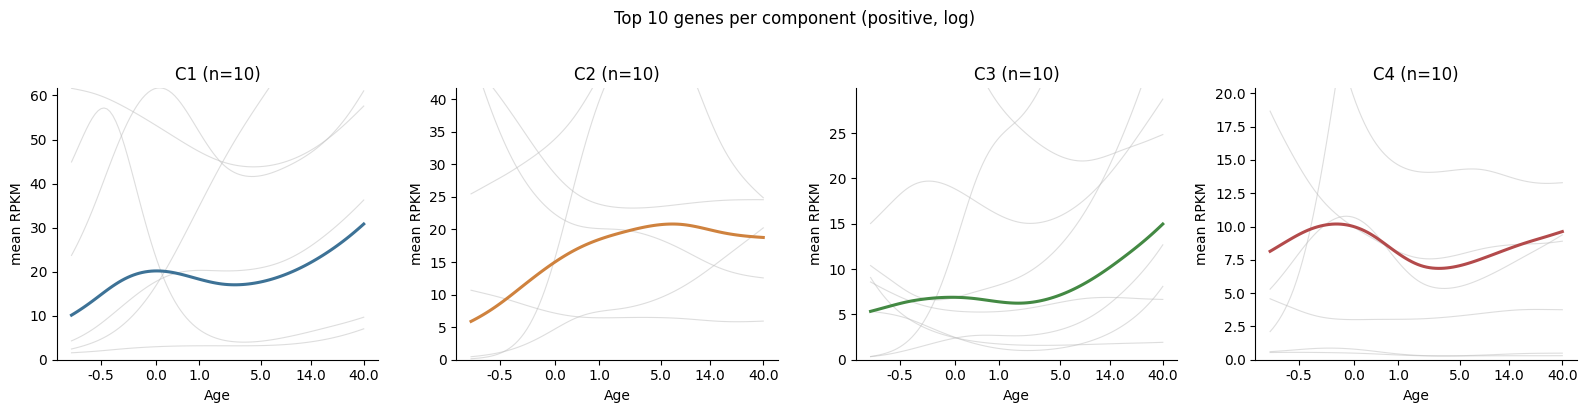

In [16]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_top_gene_average_curves(weights_df, curves_df, top_n=10, mode="positive", mean_space="log"):
    comp_order = sorted(weights_df.columns, key=lambda x: int(str(x).lstrip("C")))
    ncol = min(4, len(comp_order))
    nrow = math.ceil(len(comp_order) / ncol)
    fig, axes = plt.subplots(nrow, ncol, figsize=(4 * ncol, 4 * nrow), squeeze=False)
    axes_flat = axes.ravel()

    x_break_vals = np.array([-0.5, 0, 1, 5, 14, 40], dtype=float)
    x_breaks = np.log10(x_break_vals * 365 + 40 * 7)
    x_labels = [str(round((10 ** x - 40 * 7) / 365, 2)) for x in x_breaks]

    base_colors = sns.color_palette("tab10", len(comp_order))
    comp_colors = [sns.desaturate(c, 0.6) for c in base_colors]

    summaries = []

    for i, comp in enumerate(comp_order):
        ax = axes_flat[i]
        weights = weights_df[comp].dropna()
        if mode == "positive":
            genes = weights[weights > 0].sort_values(ascending=False).head(top_n).index.tolist()
        elif mode == "negative":
            genes = weights[weights < 0].sort_values(ascending=True).head(top_n).index.tolist()
        else:
            genes = weights.abs().sort_values(ascending=False).head(top_n).index.tolist()

        if not genes:
            ax.axis("off")
            continue

        df = curves_df[curves_df["gene"].isin(genes)].copy()
        if mean_space == "log":
            gene_curves = df.groupby(["gene", "age_log10"], as_index=False)["pred"].mean()
            gene_curves["y"] = 10 ** gene_curves["pred"]
            mean_curve = gene_curves.groupby("age_log10", as_index=False)["pred"].mean()
            mean_curve["y"] = 10 ** mean_curve["pred"]
        else:
            gene_curves = df.assign(y=10 ** df["pred"]).groupby(["gene", "age_log10"], as_index=False)["y"].mean()
            mean_curve = gene_curves.groupby("age_log10", as_index=False)["y"].mean()

        for _, gdf in gene_curves.groupby("gene", sort=False):
            ax.plot(gdf["age_log10"], gdf["y"], color="#bdbdbd", alpha=0.5, lw=0.8, zorder=1)

        ax.plot(mean_curve["age_log10"], mean_curve["y"], color=comp_colors[i], lw=2.2, zorder=3)
        ax.set_title(f"{comp} (n={len(genes)})")
        ax.set_xlabel("Age")
        ax.set_ylabel("mean RPKM")
        ax.set_xticks(x_breaks)
        ax.set_xticklabels(x_labels)
        ax.set_ylim(0, 2 * mean_curve["y"].max())
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        summaries.append({"C": comp, "mode": mode, "mean_space": mean_space, "n_genes": len(genes), "genes": ", ".join(genes)})

    for j in range(len(comp_order), len(axes_flat)):
        axes_flat[j].axis("off")

    fig.suptitle(f"Top {top_n} genes per component ({mode}, {mean_space})", y=1.02)
    fig.tight_layout()
    return fig, axes, pd.DataFrame(summaries)


fig, axes, top_gene_summary = plot_top_gene_average_curves(
    weights_df=weights,
    curves_df=curves,
    top_n=10,
    mode="positive",
    mean_space="log",
 )
display(top_gene_summary)
plt.show()

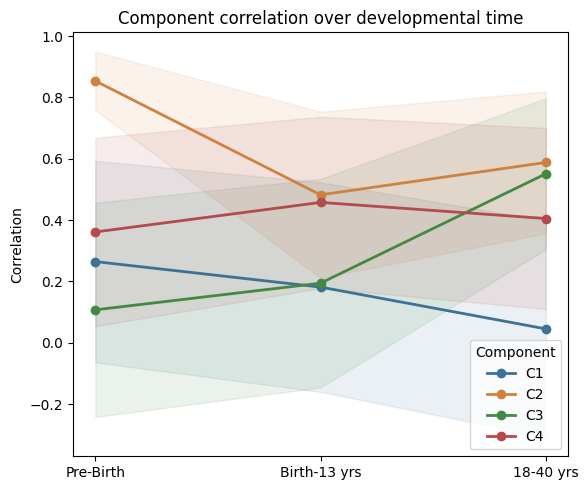

In [80]:
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt

order = ["Pre-Birth", "Birth-13 yrs", "18-40 yrs"]

plot_df = (
    bs_scores_corr.loc[bs_scores_corr["age"].isin(order), ["age", "C", "corr"]]
    .pivot_table(index="age", columns="C", values="corr", aggfunc="mean")
    .reindex(order)
)

# Explicitly make tab10 more muted
base_colors = sns.color_palette("tab10", n_colors=plot_df.shape[1])
colors = [sns.desaturate(c, 0.6) for c in base_colors]

fig, ax = plt.subplots(figsize=(6, 5))
x = np.arange(len(order))

for comp, color in zip(plot_df.columns, colors):
    comp_df = bs_scores_corr[bs_scores_corr["C"] == comp].set_index("age").reindex(order)
    lower = comp_df["corr"] - comp_df["sem"]
    upper = comp_df["corr"] + comp_df["sem"]
    ax.plot(x, comp_df["corr"], marker="o", color=color, label=comp, lw=2)
    ax.fill_between(x, lower, upper, color=color, alpha=0.1, zorder=0)

ax.set_xticks(x)
ax.set_xticklabels(order)
ax.set_xlabel("")
ax.set_ylabel("Correlation")
ax.set_title("Component correlation over developmental time")
ax.legend(title="Component")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()